# ROI Lens: Advanced Marketing Attribution & Budget Refinement Strategy
**Nexus Consumer Brands - Product Strategy Taskforce**

This Jupyter Notebook contains the complete codebase, data pipeline, and visualizations for **ROI Lens**. The notebook is structured as follows:
1. **Exploratory Data Analysis (EDA)**: Understanding campaign spends, user profiles, and touchpoint frequencies.
2. **Bot Traffic Audit**: Isolating bots, cleaning the journey log, and calculating wasted advertising spend.
3. **Multi-Touch Markov Chain Attribution**: Chronologically sequencing consumer touchpoints, building the transition matrix, solving absorption probabilities, and computing removal effects.
4. **Financial CPA Auditing**: Comparing legacy Last-Click CPA with True CPA (excluding bot waste).
5. **Convex Portfolio Reallocation**: Calibrating diminishing returns curves ($Conversions_c = k_c \cdot Spend_c^{0.75}$), scaling variables to units of ₹1 Crore, and optimizing budgets using SLSQP.
6. **Brand Persona & Trend Intelligence**: Mapping Ai Palette customer segments and trend affinities with buyers to guide targeting.

---

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy.optimize import minimize

# Plotting configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

print("Libraries loaded successfully and visualization styles configured!")

Libraries loaded successfully and visualization styles configured!


### Data Loading & Basic Exploration
We load the three core files:
- `campaign_spend.csv`: Bidding models (CPC/CPM), budget allocations, and rates.
- `user_profiles.csv`: Psychographic segments and trend affinities from Ai Palette.
- `touchpoints.csv`: Raw chronological logs of impressions, clicks, carts, and purchases.

In [2]:
# Load CSVs
spend = pd.read_csv("campaign_spend.csv")
profiles = pd.read_csv("user_profiles.csv")
touchpoints = pd.read_csv("touchpoints.csv")

print("--- DATA SHAPES ---")
print(f"Campaign Spend: {spend.shape}")
print(f"User Profiles : {profiles.shape}")
print(f"Touchpoints   : {touchpoints.shape}\n")

print("--- CAMPAIGN SPEND HEAD ---")
print(spend.head(2))
print("\n--- USER PROFILES HEAD ---")
print(profiles.head(2))
print("\n--- TOUCHPOINTS HEAD ---")
print(touchpoints.head(2))

--- DATA SHAPES ---
Campaign Spend: (50, 6)
User Profiles : (100000, 4)
Touchpoints   : (566510, 5)

--- CAMPAIGN SPEND HEAD ---
       Campaign_ID Brand_ID        Channel Pricing_Model  Cost_Rate_INR  \
0  CMP_B01_INS_285      B01      Instagram           CPM         391.98   
1  CMP_B01_GOO_434      B01  Google Search           CPC          23.41   

   Total_Budget_Allocated  
0               613144.27  
1             27896859.25  

--- USER PROFILES HEAD ---
       User_ID             Segment         Trend_Affinity Geography
0  U_B01_00000  Fitness Enthusiast  Sustainable Packaging    Tier 1
1  U_B01_00001  Fitness Enthusiast                  Vegan    Tier 1

--- TOUCHPOINTS HEAD ---
       User_ID       Timestamp      Campaign_ID          Channel  Event_Type
0  U_B01_00000  1/1/2026 19:27  CMP_B01_INF_899  Influencer Blog  Impression
1  U_B01_00001  1/1/2026 20:37  CMP_B01_GOO_434    Google Search  Impression


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18248\420976277.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_spend.index, y=channel_spend.values, palette='Blues_r')


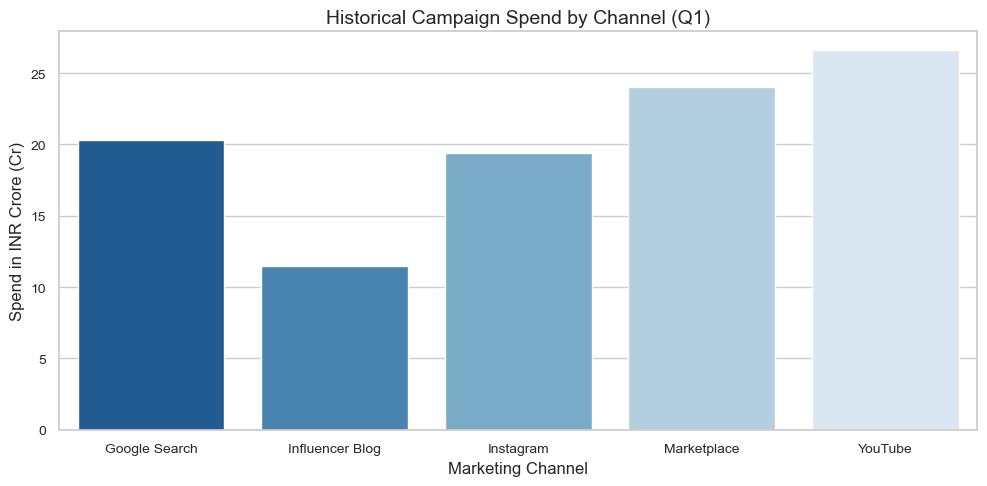

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18248\420976277.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=profiles, x='Segment', order=profiles['Segment'].value_counts().index, palette='crest')


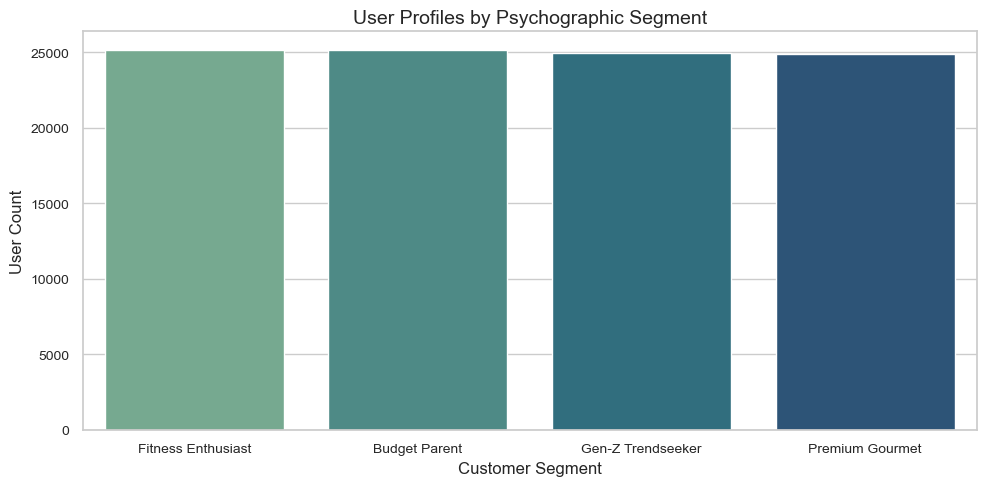

In [3]:
# Plot 1: Historical Campaign Spend by Channel
plt.figure(figsize=(10, 5))
channel_spend = spend.groupby('Channel')['Total_Budget_Allocated'].sum() / 1e7 # Scale to Crores
sns.barplot(x=channel_spend.index, y=channel_spend.values, palette='Blues_r')
plt.title('Historical Campaign Spend by Channel (Q1)')
plt.ylabel('Spend in INR Crore (Cr)')
plt.xlabel('Marketing Channel')
plt.tight_layout()
plt.show()

# Plot 2: User Profile Segment Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=profiles, x='Segment', order=profiles['Segment'].value_counts().index, palette='crest')
plt.title('User Profiles by Psychographic Segment')
plt.ylabel('User Count')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.show()

## Phase 1: Preprocessing & Bot Traffic Detection

We identify bot traffic by checking user-level event frequencies. Normal users interact occasionally and have low CTRs. Bots generate a very large number of events (impressions and clicks) in rapid succession with a perfect 1.0 CTR and 0 purchases.

In [4]:
# Convert timestamps
touchpoints['Timestamp_dt'] = pd.to_datetime(touchpoints['Timestamp'])
touchpoints['Brand_ID'] = touchpoints['Campaign_ID'].apply(lambda x: x.split('_')[1] if len(x.split('_')) > 1 else 'Unknown')

# Group by User_ID and calculate total events
user_counts = touchpoints['User_ID'].value_counts()

# Identify bot users (total touchpoints >= 60)
bot_users = user_counts[user_counts >= 60].index
touchpoints['Is_Bot'] = touchpoints['User_ID'].isin(bot_users)

print(f"Detected {len(bot_users)} bot users (out of {len(user_counts)} total users).")
print(f"Bot touchpoints: {touchpoints['Is_Bot'].sum()} ({touchpoints['Is_Bot'].mean()*100:.2f}% of total)")

# Split clean vs bot data
clean_touchpoints = touchpoints[~touchpoints['Is_Bot']].copy()
clean_touchpoints = clean_touchpoints.sort_values(by=['User_ID', 'Timestamp_dt'])

Detected 1952 bot users (out of 100000 total users).
Bot touchpoints: 193940 (34.23% of total)


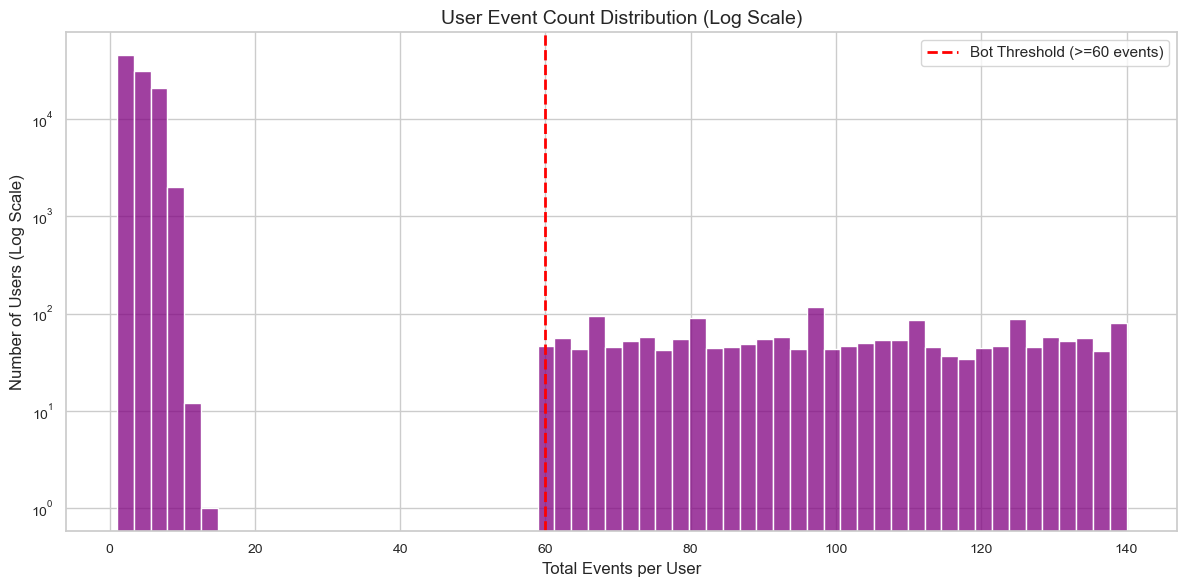

In [5]:
# Plot 3: Distribution of Event Counts per User (Bimodal Visual)
plt.figure(figsize=(12, 6))
sns.histplot(user_counts, bins=60, kde=False, color='purple')
plt.yscale('log') # Use log scale because normal users dwarf bot users in count
plt.axvline(x=60, color='red', linestyle='--', linewidth=2, label='Bot Threshold (>=60 events)')
plt.title('User Event Count Distribution (Log Scale)')
plt.xlabel('Total Events per User')
plt.ylabel('Number of Users (Log Scale)')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Calculate campaign clicks & impressions (total vs clean)
stats = touchpoints.groupby(['Campaign_ID', 'Event_Type']).size().unstack(fill_value=0)
stats_clean = clean_touchpoints.groupby(['Campaign_ID', 'Event_Type']).size().unstack(fill_value=0)

spend_df = spend.copy()
spend_df = spend_df.merge(stats, on='Campaign_ID', how='left').fillna(0)
spend_df = spend_df.rename(columns={'Click': 'Total_Clicks', 'Impression': 'Total_Impressions', 'Purchase': 'Total_Purchases'})
spend_df = spend_df.merge(stats_clean[['Click', 'Impression']], on='Campaign_ID', how='left').fillna(0)
spend_df = spend_df.rename(columns={'Click': 'Clean_Clicks', 'Impression': 'Clean_Impressions'})

# Calculate wasted budget fractions
spend_df['Wasted_Fraction'] = np.where(
    spend_df['Pricing_Model'] == 'CPC',
    (spend_df['Total_Clicks'] - spend_df['Clean_Clicks']) / (spend_df['Total_Clicks'] + 1e-5),
    (spend_df['Total_Impressions'] - spend_df['Clean_Impressions']) / (spend_df['Total_Impressions'] + 1e-5)
)
spend_df['Wasted_Budget'] = spend_df['Wasted_Fraction'] * spend_df['Total_Budget_Allocated']
spend_df['Clean_Budget'] = spend_df['Total_Budget_Allocated'] - spend_df['Wasted_Budget']

print("--- FINANCIAL BOT AUDIT SUMMARY ---")
print(f"Total Budget Allocated: INR {spend_df['Total_Budget_Allocated'].sum():,.2f}")
print(f"Total Wasted Spend:     INR {spend_df['Wasted_Budget'].sum():,.2f} ({spend_df['Wasted_Budget'].sum()/spend_df['Total_Budget_Allocated'].sum()*100:.2f}%)")
print(f"Total Clean Spend:      INR {spend_df['Clean_Budget'].sum():,.2f}")

--- FINANCIAL BOT AUDIT SUMMARY ---
Total Budget Allocated: INR 1,018,605,945.35
Total Wasted Spend:     INR 492,274,885.30 (48.33%)
Total Clean Spend:      INR 526,331,060.05


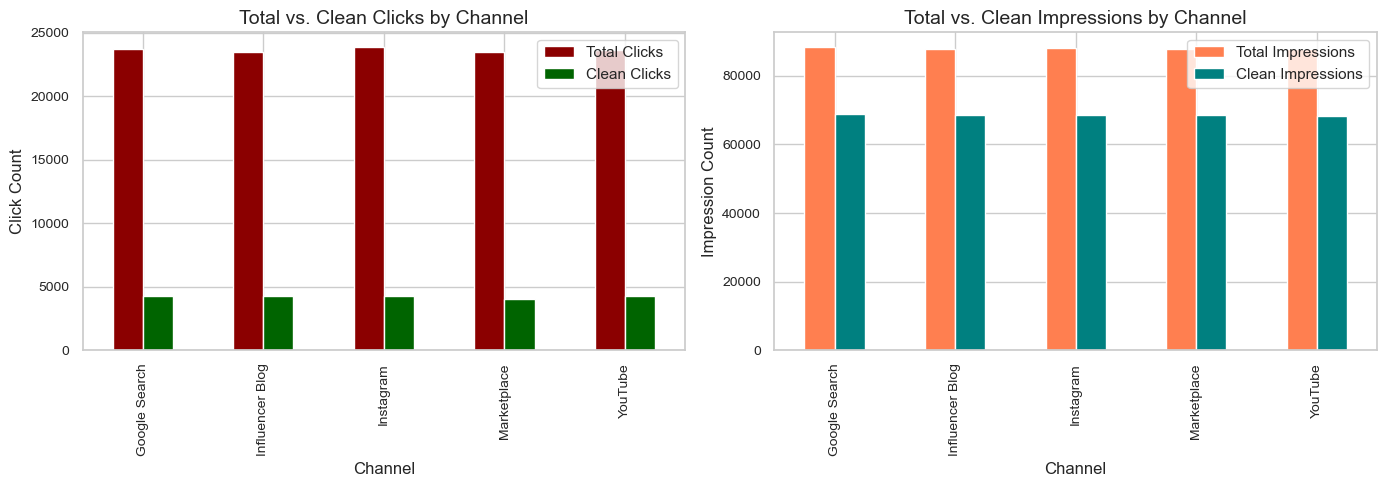

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18248\2699172077.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wasted_pct.index, y=wasted_pct.values, palette='Reds_r')


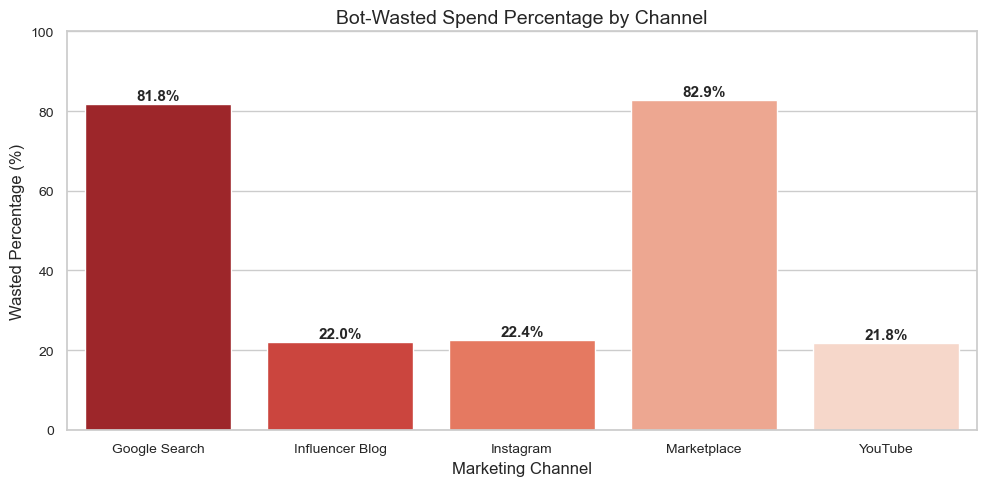

In [7]:
# Plot 4: Bot vs. Clean Clicks/Impressions by Channel
channel_stats = spend_df.groupby('Channel')[['Total_Clicks', 'Clean_Clicks', 'Total_Impressions', 'Clean_Impressions']].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Clicks comparison
channel_stats[['Total_Clicks', 'Clean_Clicks']].plot(kind='bar', ax=axes[0], color=['darkred', 'darkgreen'])
axes[0].set_title('Total vs. Clean Clicks by Channel')
axes[0].set_ylabel('Click Count')
axes[0].set_xlabel('Channel')
axes[0].legend(['Total Clicks', 'Clean Clicks'])

# Impressions comparison
channel_stats[['Total_Impressions', 'Clean_Impressions']].plot(kind='bar', ax=axes[1], color=['coral', 'teal'])
axes[1].set_title('Total vs. Clean Impressions by Channel')
axes[1].set_ylabel('Impression Count')
axes[1].set_xlabel('Channel')
axes[1].legend(['Total Impressions', 'Clean Impressions'])

plt.tight_layout()
plt.show()

# Plot 5: Wasted Budget Percentage by Channel
plt.figure(figsize=(10, 5))
channel_wasted = spend_df.groupby('Channel')[['Total_Budget_Allocated', 'Wasted_Budget']].sum()
wasted_pct = (channel_wasted['Wasted_Budget'] / channel_wasted['Total_Budget_Allocated']) * 100
sns.barplot(x=wasted_pct.index, y=wasted_pct.values, palette='Reds_r')
plt.title('Bot-Wasted Spend Percentage by Channel')
plt.ylabel('Wasted Percentage (%)')
plt.xlabel('Marketing Channel')
plt.ylim(0, 100)
for i, val in enumerate(wasted_pct.values):
    plt.text(i, val + 1, f"{val:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Phase 1: Multi-Touch Attribution (MTA) Markov Chain Model

We build a Markov Chain attribution model for each of the 10 brands. The consumer touchpoints are sequenced chronologically. For a user who converted, the channel of the purchase event itself is added as the final converting touchpoint before transition to absorbing state `Purchase`. Non-converting users transition to absorbing state `Null`. We compute the transition probability matrix, solve the absorption probabilities using the fundamental matrix, and calculate the removal effects.

In [8]:
def get_markov_attribution(journeys):
    transitions = defaultdict(lambda: defaultdict(int))
    for journey in journeys:
        transitions['Start'][journey[0]] += 1
        for i in range(len(journey) - 1):
            transitions[journey[i]][journey[i+1]] += 1
            
    prob_matrix = defaultdict(dict)
    for state, next_states in transitions.items():
        total_transitions = sum(next_states.values())
        for next_state, count in next_states.items():
            prob_matrix[state][next_state] = count / total_transitions
            
    prob_matrix['Purchase']['Purchase'] = 1.0
    prob_matrix['Null']['Null'] = 1.0
    
    channels = ['Instagram', 'Google Search', 'Influencer Blog', 'YouTube', 'Marketplace']
    all_trans_states = ['Start'] + channels
    state_to_idx = {state: idx for idx, state in enumerate(all_trans_states)}
    num_trans = len(all_trans_states)
    
    Q = np.zeros((num_trans, num_trans))
    R = np.zeros((num_trans, 2))
    
    for state in all_trans_states:
        idx = state_to_idx[state]
        for next_state, prob in prob_matrix[state].items():
            if next_state == 'Purchase':
                R[idx, 0] = prob
            elif next_state == 'Null':
                R[idx, 1] = prob
            elif next_state in state_to_idx:
                Q[idx, state_to_idx[next_state]] = prob
                
    I = np.eye(num_trans)
    try:
        N = np.linalg.inv(I - Q)
        B = N.dot(R)
        base_conversion_prob = B[state_to_idx['Start'], 0]
    except:
        return {c: 0.2 for c in channels}, None
        
    removal_effects = {}
    for channel in channels:
        Q_mod = Q.copy()
        R_mod = R.copy()
        c_idx = state_to_idx[channel]
        Q_mod[c_idx, :] = 0.0
        R_mod[c_idx, 0] = 0.0
        R_mod[c_idx, 1] = 1.0
        
        try:
            N_mod = np.linalg.inv(I - Q_mod)
            B_mod = N_mod.dot(R_mod)
            mod_conversion_prob = B_mod[state_to_idx['Start'], 0]
            removal_effects[channel] = 1.0 - (mod_conversion_prob / base_conversion_prob)
        except:
            removal_effects[channel] = 0.0
            
    total_re = sum(removal_effects.values())
    weights = {channel: re / total_re for channel, re in removal_effects.items()} if total_re > 0 else {c: 0.2 for c in channels}
    return weights, prob_matrix

brands = sorted(clean_touchpoints['Brand_ID'].unique())
if 'Unknown' in brands: brands.remove('Unknown')

brand_markov_weights = {}
brand_purchases_count = {}
brand_last_click_weights = {}
sample_prob_matrix = None

for brand in brands:
    b_tp = clean_touchpoints[clean_touchpoints['Brand_ID'] == brand]
    user_journeys = b_tp.groupby('User_ID')
    
    journeys = []
    last_touch = defaultdict(int)
    total_p = 0
    
    for uid, group in user_journeys:
        events = group.sort_values('Timestamp_dt')
        seq = []
        purchased = False
        for _, row in events.iterrows():
            seq.append(row['Channel'])
            if row['Event_Type'] == 'Purchase':
                purchased = True
                break
        if purchased:
            seq.append('Purchase')
            total_p += 1
            last_touch[seq[-2]] += 1
        else:
            seq.append('Null')
        journeys.append(seq)
        
    weights, prob_matrix = get_markov_attribution(journeys)
    brand_markov_weights[brand] = weights
    brand_purchases_count[brand] = total_p
    brand_last_click_weights[brand] = {c: last_touch[c]/total_p for c in ['Instagram', 'Google Search', 'Influencer Blog', 'YouTube', 'Marketplace']} if total_p > 0 else {}
    
    if brand == 'B01':
        sample_prob_matrix = prob_matrix

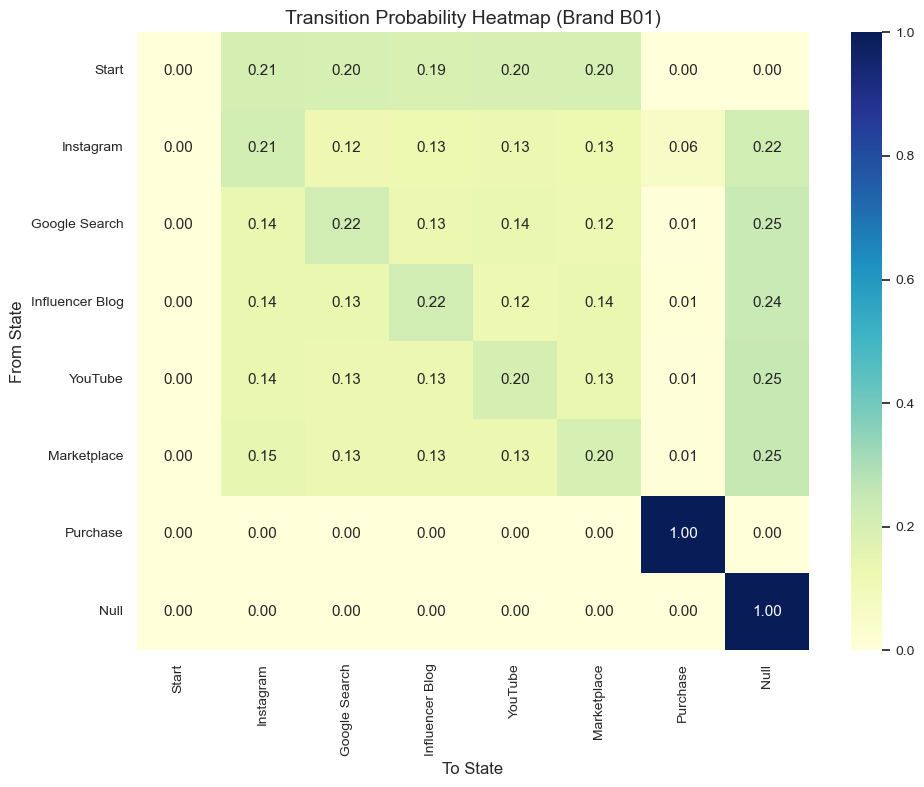

In [9]:
# Plot 6: Markov Transition Matrix Heatmap (Brand B01 Example)
channels = ['Instagram', 'Google Search', 'Influencer Blog', 'YouTube', 'Marketplace']
all_states = ['Start'] + channels + ['Purchase', 'Null']
matrix_data = np.zeros((len(all_states), len(all_states)))

for i, s_from in enumerate(all_states):
    for j, s_to in enumerate(all_states):
        matrix_data[i, j] = sample_prob_matrix.get(s_from, {}).get(s_to, 0.0)

df_heatmap = pd.DataFrame(matrix_data, index=all_states, columns=all_states)

plt.figure(figsize=(10, 8))
sns.heatmap(df_heatmap, annot=True, cmap='YlGnBu', fmt='.2f', cbar=True)
plt.title('Transition Probability Heatmap (Brand B01)')
plt.ylabel('From State')
plt.xlabel('To State')
plt.tight_layout()
plt.show()

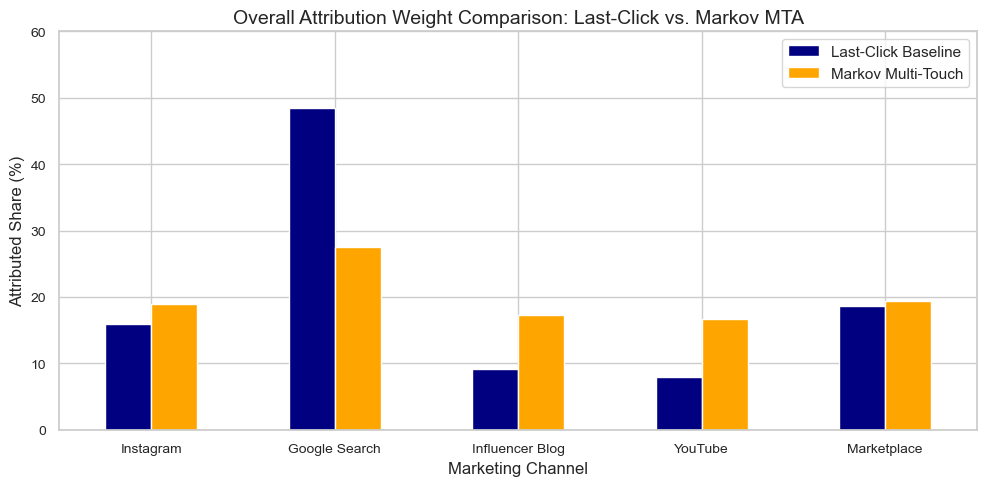

In [10]:
# Plot 7: Last-Touch vs. Markov Weights Overall Comparison
overall_last_touch = defaultdict(float)
overall_markov = defaultdict(float)
total_purchases_all = sum(brand_purchases_count.values())

for brand in brands:
    b_p = brand_purchases_count[brand]
    for c in ['Instagram', 'Google Search', 'Influencer Blog', 'YouTube', 'Marketplace']:
        overall_last_touch[c] += brand_last_click_weights[brand].get(c, 0.0) * b_p
        overall_markov[c] += brand_markov_weights[brand].get(c, 0.0) * b_p

df_compare = pd.DataFrame({
    'Last-Click Baseline': [overall_last_touch[c] / total_purchases_all * 100 for c in overall_last_touch],
    'Markov Multi-Touch': [overall_markov[c] / total_purchases_all * 100 for c in overall_markov]
}, index=overall_last_touch.keys())

df_compare.plot(kind='bar', color=['navy', 'orange'], figsize=(10, 5))
plt.title('Overall Attribution Weight Comparison: Last-Click vs. Markov MTA')
plt.ylabel('Attributed Share (%)')
plt.xlabel('Marketing Channel')
plt.ylim(0, 60)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Phase 1: Legacy CPA vs. True CPA Audit

We audit the cost metrics for each campaign. Legacy CPA divides the entire allocated budget by last-click conversions. True CPA divides the *clean* budget by Markov-attributed conversions, stripping away bot waste and accounting for multi-touch paths.

In [11]:
def get_m_weight(row):
    return brand_markov_weights[row['Brand_ID']][row['Channel']]

spend_df['Markov_Weight'] = spend_df.apply(get_m_weight, axis=1)

def get_attr_purchases(row):
    brand = row['Brand_ID']
    total_p = brand_purchases_count.get(brand, 0)
    return row['Markov_Weight'] * total_p

spend_df['Attributed_Purchases'] = spend_df.apply(get_attr_purchases, axis=1)
spend_df['Legacy_CPA'] = spend_df['Total_Budget_Allocated'] / (spend_df['Total_Purchases'] + 1e-5)
spend_df['True_CPA'] = spend_df['Clean_Budget'] / (spend_df['Attributed_Purchases'] + 1e-5)

print("CPA calculation and financial audit complete.")

CPA calculation and financial audit complete.


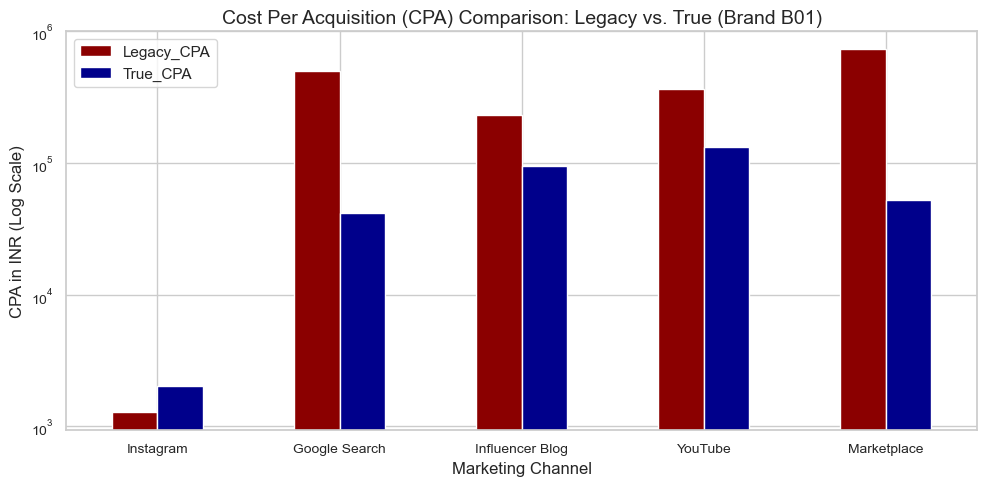

In [12]:
# Plot 8: Legacy CPA vs. True CPA Comparison (Brand B01 Example)
b01_spend = spend_df[spend_df['Brand_ID'] == 'B01'].copy()
df_cpa = b01_spend.set_index('Channel')[['Legacy_CPA', 'True_CPA']]

df_cpa.plot(kind='bar', color=['darkred', 'darkblue'], logy=True, figsize=(10, 5)) # Use log scale because values vary by orders of magnitude
plt.title('Cost Per Acquisition (CPA) Comparison: Legacy vs. True (Brand B01)')
plt.ylabel('CPA in INR (Log Scale)')
plt.xlabel('Marketing Channel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Phase 2: Portfolio Reallocation & Diminishing Returns Optimization

We calibrate the diminishing returns curves per channel: $Conversions_c = k_c \cdot Spend_c^{0.75}$. To ensure convergence of the SLSQP optimizer, variables are scaled to units of ₹1 Crore ($1e7$ INR).
We optimize the ₹10 Crore budget per brand to maximize total conversions under three scenarios:
- **Scenario 1**: Bots Blocked, Unconstrained.
- **Scenario 2**: Bots Remain, Unconstrained.
- **Scenario 1 Constrained**: Bots Blocked, with diversification caps (Min 10% / Max 50% spend per channel).

In [13]:
BETA = 0.75
BUDGET_LIMIT = 100000000.0
SCALE = 1e7
scaled_limit = BUDGET_LIMIT / SCALE

# Calibrate k_c
spend_df['k_c'] = spend_df['Attributed_Purchases'] / (spend_df['Clean_Budget'] ** BETA + 1e-10)

opt_results = []
for brand in brands:
    brand_df = spend_df[spend_df['Brand_ID'] == brand].copy()
    channels = brand_df['Channel'].tolist()
    k_vals = brand_df['k_c'].tolist()
    wasted_fracs = brand_df['Wasted_Fraction'].tolist()
    prev_budgets = brand_df['Total_Budget_Allocated'].tolist()
    prev_clean_budgets = brand_df['Clean_Budget'].tolist()
    prev_purchases = brand_df['Attributed_Purchases'].tolist()
    
    # Scaled K coefficients for the solver
    K_vals = [k * (SCALE ** BETA) for k in k_vals]
    
    # Solver 1: Scenario 1 (Bots Blocked: full spend is clean spend)
    def obj_blocked(y):
        return -sum(K * (max(val, 0.0) ** BETA) for K, val in zip(K_vals, y))
        
    # Solver 2: Scenario 2 (Bots Remain: only a fraction of spend is clean)
    def obj_remain(y):
        return -sum(K * (((1 - wf) * max(val, 0.0)) ** BETA) for K, wf, val in zip(K_vals, wasted_fracs, y))
        
    cons = ({'type': 'eq', 'fun': lambda y: sum(y) - scaled_limit})
    x0 = [scaled_limit / 5.0] * 5
    
    # Run Unconstrained Scenario 1
    bounds_unconstrained = [(0, scaled_limit) for _ in range(5)]
    res_blocked = minimize(obj_blocked, x0, method='SLSQP', bounds=bounds_unconstrained, constraints=cons)
    
    # Run Unconstrained Scenario 2
    res_remain = minimize(obj_remain, x0, method='SLSQP', bounds=bounds_unconstrained, constraints=cons)
    
    # Run Strategic Constrained Scenario 1 (Min 10%, Max 50% spend)
    bounds_constrained = [(1.0, 5.0) for _ in range(5)] # In scaled units (1 Crore to 5 Crore)
    res_constrained = minimize(obj_blocked, x0, method='SLSQP', bounds=bounds_constrained, constraints=cons)
    
    opt_blocked_spend = res_blocked.x * SCALE
    opt_remain_spend = res_remain.x * SCALE
    opt_constrained_spend = res_constrained.x * SCALE
    
    for i, channel in enumerate(channels):
        opt_results.append({
            'Brand_ID': brand,
            'Channel': channel,
            'Prev_Budget': prev_budgets[i],
            'Prev_Clean_Budget': prev_clean_budgets[i],
            'Prev_Attributed_Purchases': prev_purchases[i],
            'Wasted_Fraction': wasted_fracs[i],
            'Opt_Spend_Bots_Blocked': opt_blocked_spend[i],
            'Opt_Spend_Bots_Remain': opt_remain_spend[i],
            'Opt_Spend_Bots_Blocked_Constrained': opt_constrained_spend[i],
            'Expected_Purchases_Bots_Blocked': k_vals[i] * (opt_blocked_spend[i] ** BETA),
            'Expected_Purchases_Bots_Remain': k_vals[i] * (((1 - wasted_fracs[i]) * opt_remain_spend[i]) ** BETA),
            'Expected_Purchases_Bots_Blocked_Constrained': k_vals[i] * (opt_constrained_spend[i] ** BETA)
        })

opt_df = pd.DataFrame(opt_results)
opt_df.to_csv("roi_lens_optimized_allocations.csv", index=False)
print("Optimization complete and output exported to roi_lens_optimized_allocations.csv")

Optimization complete and output exported to roi_lens_optimized_allocations.csv


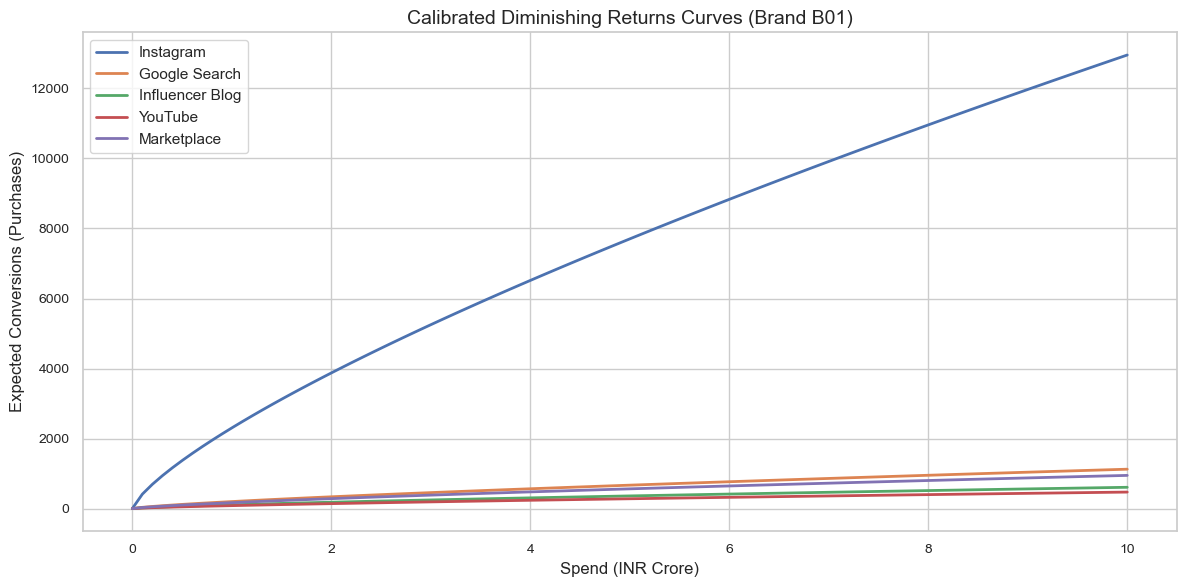

In [14]:
# Plot 9: Diminishing Returns Curves (Brand B01 Example)
b01_opt = opt_df[opt_df['Brand_ID'] == 'B01'].copy()
spend_range = np.linspace(0, 1e8, 100) # From 0 to 10 Crore

plt.figure(figsize=(12, 6))
for _, row in b01_opt.iterrows():
    k = row['Prev_Attributed_Purchases'] / (row['Prev_Clean_Budget'] ** BETA + 1e-10)
    expected_conv = k * (spend_range ** BETA)
    plt.plot(spend_range / 1e7, expected_conv, label=row['Channel'], linewidth=2)

plt.title('Calibrated Diminishing Returns Curves (Brand B01)')
plt.xlabel('Spend (INR Crore)')
plt.ylabel('Expected Conversions (Purchases)')
plt.legend()
plt.tight_layout()
plt.show()

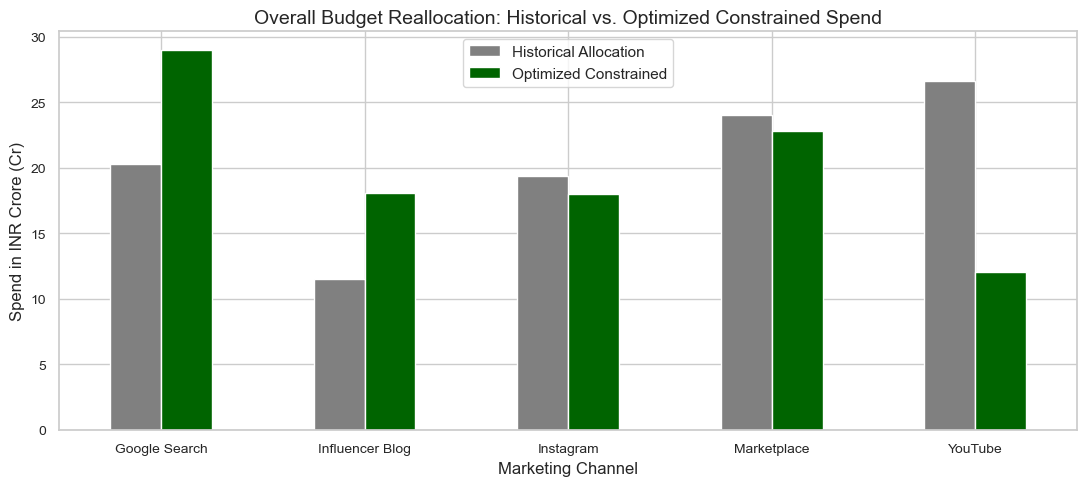

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18248\262680788.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=totals, y=scenarios, palette='viridis')


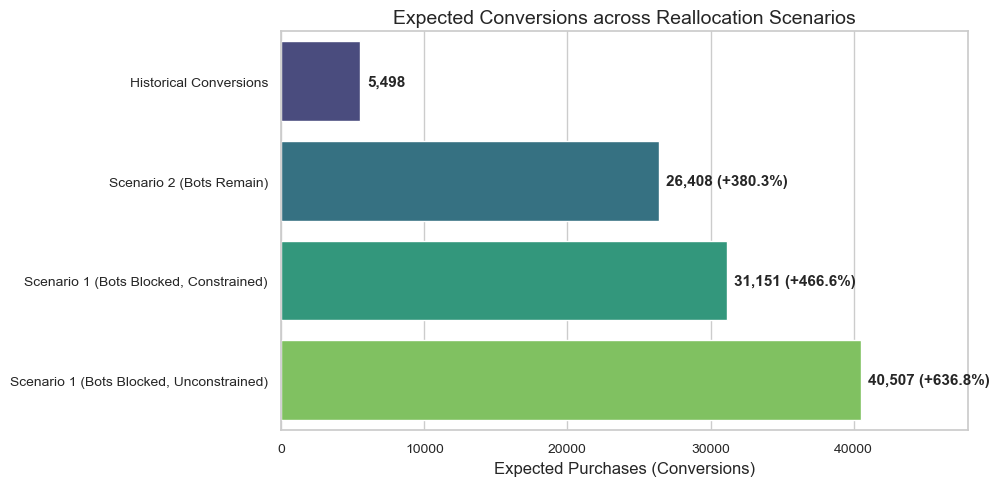

In [15]:
# Plot 10: Budget Reallocation Comparison (Overall Channels)
overall_alloc = opt_df.groupby('Channel')[['Prev_Budget', 'Opt_Spend_Bots_Blocked_Constrained']].sum() / 1e7
overall_alloc.columns = ['Historical Allocation', 'Optimized Constrained']

overall_alloc.plot(kind='bar', color=['grey', 'darkgreen'], figsize=(11, 5))
plt.title('Overall Budget Reallocation: Historical vs. Optimized Constrained Spend')
plt.ylabel('Spend in INR Crore (Cr)')
plt.xlabel('Marketing Channel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 11: Conversions Gains Across Scenarios
scenarios = ['Historical Conversions', 'Scenario 2 (Bots Remain)', 'Scenario 1 (Bots Blocked, Constrained)', 'Scenario 1 (Bots Blocked, Unconstrained)']
totals = [
    total_purchases_all,
    opt_df['Expected_Purchases_Bots_Remain'].sum(),
    opt_df['Expected_Purchases_Bots_Blocked_Constrained'].sum(),
    opt_df['Expected_Purchases_Bots_Blocked'].sum()
]

plt.figure(figsize=(10, 5))
sns.barplot(x=totals, y=scenarios, palette='viridis')
plt.title('Expected Conversions across Reallocation Scenarios')
plt.xlabel('Expected Purchases (Conversions)')
for i, val in enumerate(totals):
    plt.text(val + 500, i, f"{val:,.0f} (+{(val/total_purchases_all - 1)*100:.1f}%)" if i > 0 else f"{val:,.0f}", va='center', fontweight='bold')
plt.xlim(0, 48000)
plt.tight_layout()
plt.show()

## Phase 2: Brand Persona & Trend Affinity Integration

We merge buyer segments and trend affinities from `user_profiles.csv` with our purchasing users to identify brand-level target audiences. This allows us to align product positioning and marketing creatives with trend-forecasting results.

In [16]:
# Merge buyers with profiles
clean_buyers = clean_touchpoints[clean_touchpoints['Event_Type'] == 'Purchase'].copy()
buyers_profiles = clean_buyers.merge(profiles, on='User_ID', how='inner')

print(f"Successfully mapped {buyers_profiles.shape[0]} unique buyer profiles.\n")

# Group segments by Brand ID
brand_segments = buyers_profiles.groupby(['Brand_ID', 'Segment']).size().unstack(fill_value=0)
brand_trends = buyers_profiles.groupby(['Brand_ID', 'Trend_Affinity']).size().unstack(fill_value=0)

Successfully mapped 5498 unique buyer profiles.



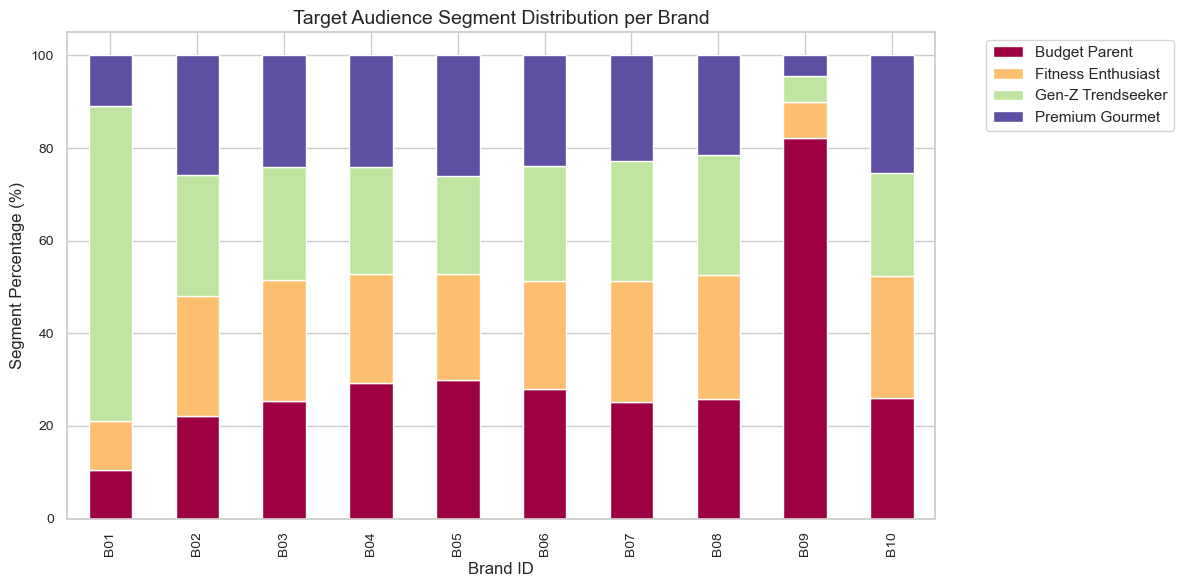

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18248\4187201795.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=b01_trends.values, y=b01_trends.index, ax=axes[0], palette='crest')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18248\4187201795.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=b09_trends.values, y=b09_trends.index, ax=axes[1], palette='rocket')


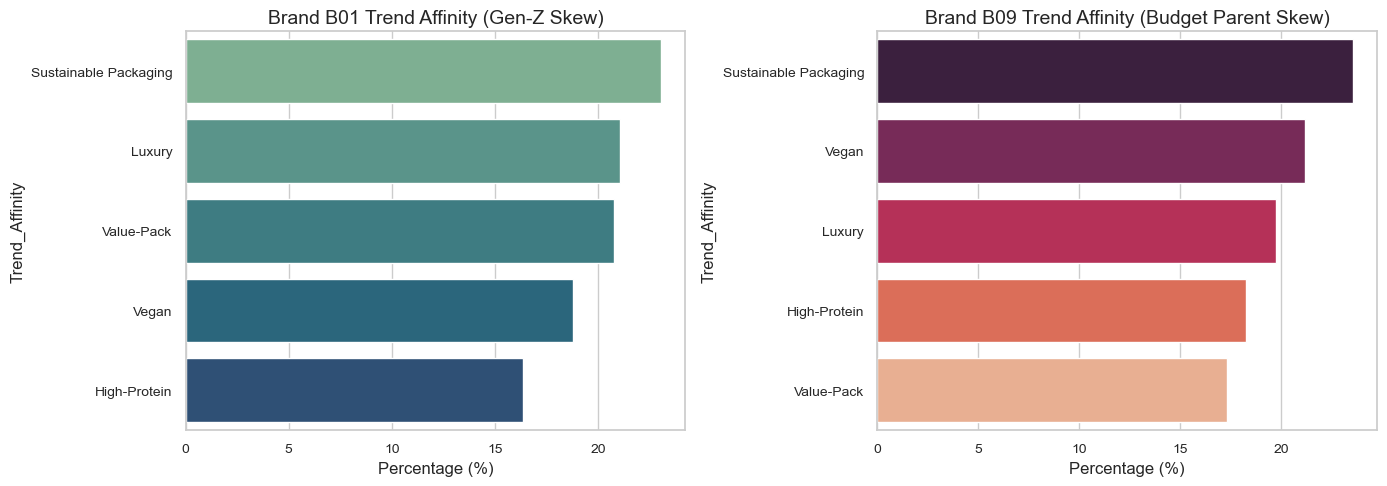

In [17]:
# Plot 12: Buyer Psychographic Segment Distribution by Brand (Stacked Bar)
brand_segments_pct = brand_segments.div(brand_segments.sum(axis=1), axis=0) * 100
brand_segments_pct.plot(kind='bar', stacked=True, cmap='Spectral', figsize=(12, 6))
plt.title('Target Audience Segment Distribution per Brand')
plt.ylabel('Segment Percentage (%)')
plt.xlabel('Brand ID')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot 13: Buyer Trend Affinity distribution for B01 and B09
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# B01 Trends
b01_trends = buyers_profiles[buyers_profiles['Brand_ID'] == 'B01']['Trend_Affinity'].value_counts(normalize=True) * 100
sns.barplot(x=b01_trends.values, y=b01_trends.index, ax=axes[0], palette='crest')
axes[0].set_title('Brand B01 Trend Affinity (Gen-Z Skew)')
axes[0].set_xlabel('Percentage (%)')

# B09 Trends
b09_trends = buyers_profiles[buyers_profiles['Brand_ID'] == 'B09']['Trend_Affinity'].value_counts(normalize=True) * 100
sns.barplot(x=b09_trends.values, y=b09_trends.index, ax=axes[1], palette='rocket')
axes[1].set_title('Brand B09 Trend Affinity (Budget Parent Skew)')
axes[1].set_xlabel('Percentage (%)')

plt.tight_layout()
plt.show()